In [1]:
from utils import *

## Load PCA Layers definitions from YAML

In [2]:
## Define PCA dataset to use. This will be used in the output file names
pca_dataset = 'pca_nominations'
pca_status_filter = [
    'final/submit',
    # 'draft'
    ]
datestamp = datetime.now().strftime("%Y%m%d")

## Define Evaluation output files
eval_type_file = f'pca_type_assignment_{pca_dataset}_{datestamp}.csv'
eval_matrix_file = f'pca_matrix_{pca_dataset}_{datestamp}.csv'
eval_dir = '_data/evaluation_assignments'

print('Evaluation Output files will be saved to the Evaluation directory:', eval_dir)

Evaluation Output files will be saved to the Evaluation directory: _data/evaluation_assignments


In [3]:
## Load data dictionary
pca_data = load_dict_from_yaml()
[print(f"{k}: {v['use']}") for k,v in pca_data.items()]

pca: pca_geographies
pca_ammend: pca_geographies
pca_nominations: pca_geographies
natural_land: pca_type
working_land: pca_type
urban_greening: pca_type
recreation: pca_type
climate_adaptation: pca_type
ugb: ugb


[None, None, None, None, None, None, None, None, None]

In [4]:
## Create subset dictionaries
## PCA Geographies. Select either 'pca' or 'pca_ammend' for the PCA geographies

## Option A: PCA
# pca_geo = pca_data['pca']

## Option B: PCA DRAFT Amendement
# pca_geo = pca_data['pca_ammend']

## Option C: PCA Nominations (From PCA Nomination Tool)
pca_geo = pca_data[pca_dataset]

# PCA Types
pca_types = create_subset_dict(pca_data, 'use', 'pca_type')
# UGB
ugb = pca_data['ugb']

## Load PCA Layers from Feather Files

Shape__Area and Shape__Length columns dropped from the data_load dataframe
chng_status
final/submit    41
dtype: int64


<Axes: >

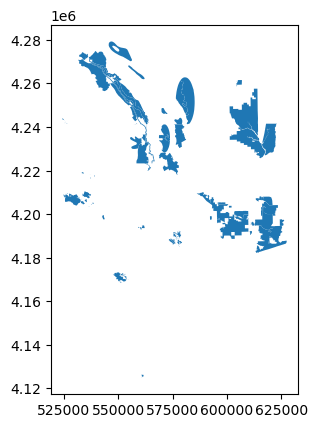

In [5]:
## Load PCA Geographies from Feather file
# pca_geo['data_load'] = open_feather(pca_geo['filename'])

## Load PCA Geographies from GeoJSON file
pca_geo['data_load'] = gpd.read_file('_data/geojson_files/priority_conservation_area_bndy_wrk.geojson') ## Use Output to GeoJSON
pca_geo['data_load'] = pca_geo['data_load'].to_crs('EPSG:26910')
try:
    pca_geo['data_load'] = pca_geo['data_load'].drop(columns=['Shape__Area', 'Shape__Length'])
    print('Shape__Area and Shape__Length columns dropped from the data_load dataframe')
except:
    pass

## Apply Status filter
pca_geo['data'] = pca_geo['data_load'][pca_geo['data_load']['chng_status'].isin(pca_status_filter)]

## Process PCA Geographies
process_data_load(pca_geo, data_key='data')
print(pca_geo['data'].groupby('chng_status').size())

pca_geo['data'].plot()

## Load PCA Footprints from Feather Files

Loading data for natural_land
Opening file from _data/feather_files/natural_land_footprint.feather
Footprint loaded successfully from natural_land_footprint

Loading data for working_land
Opening file from _data/feather_files/working_land_footprint.feather
Footprint loaded successfully from working_land_footprint

Loading data for urban_greening
Opening file from _data/feather_files/urban_greening_footprint.feather
Footprint loaded successfully from urban_greening_footprint

Loading data for recreation
Opening file from _data/feather_files/recreation_footprint.feather
Footprint loaded successfully from recreation_footprint

Loading data for climate_adaptation
Opening file from _data/feather_files/climate_adaptation_footprint.feather
Footprint loaded successfully from climate_adaptation_footprint



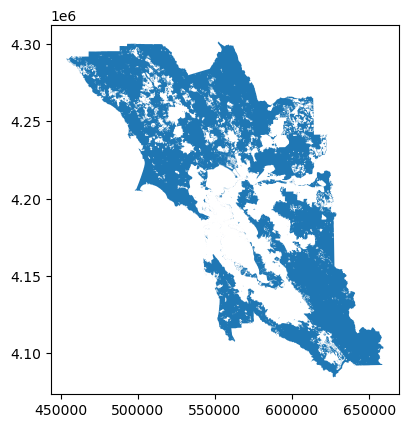

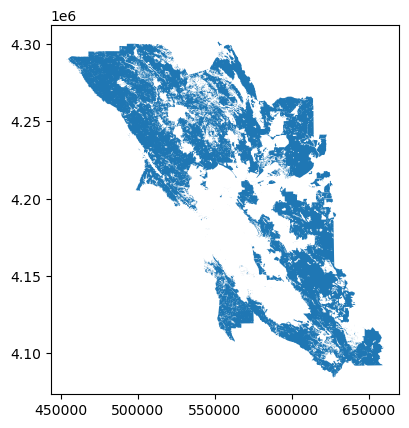

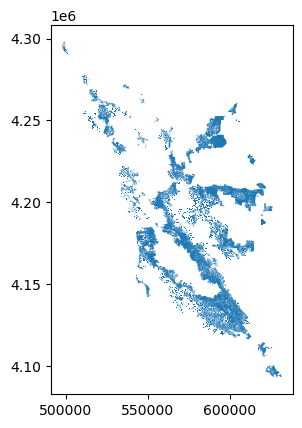

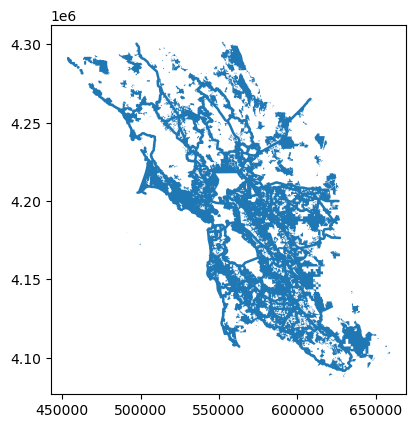

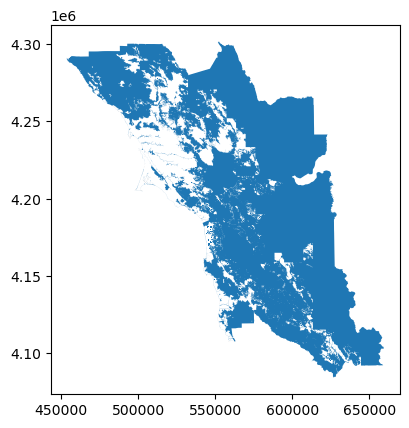

In [6]:
load_footprints_for_dict(pca_types)

## Evaluation Assignment #1 PCA Geographies to PCA Types

### Assign PCA Type Footprints to PCA Geographies

In [7]:
assign_footprints_from_dictionary(pca_geo, pca_types, 'flag')

Dataset natural_land: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 0.8129 seconds
Calculating area_sq_m
Dataset natural_land: Assignment of Footprint complete

Dataset working_land: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 1.9483 seconds
Calculating area_sq_m
Dataset working_land: Assignment of Footprint complete

Dataset urban_greening: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 9.3048 seconds
Calculating area_sq_m
Dataset urban_greening: Assignment of Footprint complete

Dataset recreation: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 0.9434 seconds
Calculating area_sq_m
Dataset recreation: Assignment of Footprint complete

Dataset climate_adaptation: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence
took 7.2758 seconds
Calculating area_sq_m
Dataset climate_adaptation: Assignment of Footprint complete



/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [8]:
## Display Assignment of Footprint for PCA Types
for pca_type, type_att in pca_types.items():
    try:
        print('Displaying Assignment of Footprint for PCA Type:', pca_type)
        display(type_att['assignment'].sample(3))
    except:
        print(f'Display of Assignment of Footprint for PCA Type {pca_type} failed!')

Displaying Assignment of Footprint for PCA Type: natural_land


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1nl,base_sq_m,1nl_intersect_sq_m,area_share,1nl_share_pct
33,164,None,Solano County,Western Hills (Recreation),Solano County,None,None,None,None,No,...,klyons@bayareametro.gov_MTC,final/submit,SL109,34,3.704454e+06,1.0,3.704454e+06,132168.374966,0.035678,0.035678
20,72,SL102,Vallejo,Napa-Sonoma Marshes Wildlife Area,City of Vallejo,None,None,None,None,No,...,klyons@bayareametro.gov_MTC,final/submit,None,21,1.152253e+06,1.0,1.152253e+06,525747.006838,0.456277,0.456277
39,189,None,Contra Costa County,East Contra Costa County Habitat Conservation ...,Contra Costa County,None,None,None,None,No,...,klyons@bayareametro.gov_MTC,final/submit,CC28,40,2.879297e+07,1.0,2.879297e+07,164724.096616,0.005721,0.005721


Displaying Assignment of Footprint for PCA Type: working_land


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1wl,base_sq_m,1wl_intersect_sq_m,area_share,1wl_share_pct
14,64,SL5,Solano County,Suisun Valley,Solano County,None,None,None,None,Yes,...,,final/submit,None,15,3.521495e+07,1.0,3.521495e+07,3.279128e+07,0.931175,0.931175
26,129,None,City of Albany,Albany Bay Trail/Waterfront - Recreation Only,City of Albany,Leslie Mendez,lmendez@albanyca.org,Leslie Mendez,lmendez@albanyca.org,No,...,,final/submit,AL38,27,4.211861e+05,NaN,4.211861e+05,NaN,NaN,NaN
12,44,MR22,Novato,Carmel Open Space,City of Novato,None,None,None,None,No,...,,final/submit,None,13,8.425840e+03,NaN,8.425840e+03,NaN,NaN,NaN


Displaying Assignment of Footprint for PCA Type: urban_greening


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1ug,base_sq_m,1ug_intersect_sq_m,area_share,1ug_share_pct
30,154,None,Marin County,Central Marin Ridge Lands Recreation,Marin County Parks and Open Space Department,None,None,None,None,No,...,pmilliken@bayareametro.gov_MTC,final/submit,MR28,31,9.186782e+06,1.0,9.186782e+06,1.428351e+06,0.155479,0.155479
12,44,MR22,Novato,Carmel Open Space,City of Novato,None,None,None,None,No,...,,final/submit,None,13,8.425840e+03,1.0,8.425840e+03,1.418640e+03,0.168368,0.168368
11,43,MR24,Novato,Hill Recreation and Arroyo Avichi Creek Area,City of Novato,None,None,None,None,No,...,,final/submit,None,12,9.362356e+04,1.0,9.362356e+04,6.991936e+04,0.746814,0.746814


Displaying Assignment of Footprint for PCA Type: recreation


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1r,base_sq_m,1r_intersect_sq_m,area_share,1r_share_pct
19,71,SL101,Vallejo,White Slough Wetlands Area,City of Vallejo,None,None,None,None,Yes,...,klyons@bayareametro.gov_MTC,final/submit,None,20,6.577576e+05,1,6.577576e+05,6.573131e+05,0.999324,0.999324
31,156,None,Solano County,Tri City and County Cooperative Planning Area ...,Solano County,Mathew Walsh,MWalsh@solanocounty.gov,None,None,Yes,...,klyons@bayareametro.gov_MTC,final/submit,SL107,32,3.616790e+07,1,3.616790e+07,2.125399e+07,0.587648,0.587648
17,69,SL104,Solano County,Dixon Agricultural Service Area,Solano County,None,None,None,None,No,...,,final/submit,None,18,4.691420e+06,1,4.691420e+06,1.233172e+06,0.262857,0.262857


Displaying Assignment of Footprint for PCA Type: climate_adaptation


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1ca,base_sq_m,1ca_intersect_sq_m,area_share,1ca_share_pct
38,188,None,Contra Costa County,East Contra Costa County Habitat Conservation ...,Contra Costa County,None,None,None,None,No,...,klyons@bayareametro.gov_MTC,final/submit,CC27,39,2.584726e+07,1,2.584726e+07,2.584726e+07,1.000000,1.000000
31,156,None,Solano County,Tri City and County Cooperative Planning Area ...,Solano County,Mathew Walsh,MWalsh@solanocounty.gov,None,None,Yes,...,klyons@bayareametro.gov_MTC,final/submit,SL107,32,3.616790e+07,1,3.616790e+07,2.487686e+07,0.687816,0.687816
27,139,None,San Anselmo,Sorich Ranch,Town of San Anselmo,Lindsey Klein,lklein@sananselmo.gov,Lindsey Klein,lklein@sananselmo.gov,No,...,klyons@bayareametro.gov_MTC,final/submit,MR26,28,2.314111e+05,1,2.314111e+05,6.392404e+03,0.027624,0.027624


### Integrate Assignments of PCA Types into single Assignment file

In [9]:
## Prepare PCA Types Assignments
pca_geo['assignment'] = pca_geo[data_key(pca_geo)].drop(columns=['geometry'])
## Merge PCA Geographies to PCA Types Assignments 
for pca_type, type_att in pca_types.items():
    try:
        flag = type_att['flag']
        cols = ['gdf_id', flag, f"{flag}_intersect_sq_m", f"{flag}_share_pct"]
        pca_geo['assignment'] = pd.merge(
            pca_geo['assignment'],
            type_att['assignment'][cols].fillna(0),
            on='gdf_id',
            how='left'
            )
        print(f'Assignment of Footprint for PCA Type {pca_type} completed\n')
    except:
        print(f'Assignment of Footprint for PCA Type {pca_type} failed!\n')

Assignment of Footprint for PCA Type natural_land completed

Assignment of Footprint for PCA Type working_land completed

Assignment of Footprint for PCA Type urban_greening completed

Assignment of Footprint for PCA Type recreation completed

Assignment of Footprint for PCA Type climate_adaptation completed



## Evaluation Assignment #2 PCA to UGB

### Load Footprint for UGB

Opening file from _data/feather_files/ugb_footprint.feather


<Axes: >

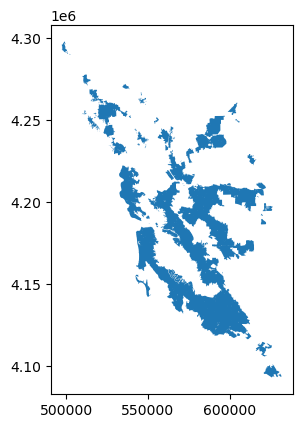

In [10]:
## Load UGB Footprint from Feather file
footprint_filename = f"{ugb['filename']}_footprint"
ugb["footprint"] = open_feather(footprint_filename)
ugb['footprint'].plot()

### Assign UGB Footprint to PCA Geographies

In [11]:
print(f"Dataset {ugb['name']}: Starting Assignment of Footprint")
print(f"Using: {data_key(pca_geo)}")
flag_name = ugb['flag']
ugb['assignment'] = assign_footprint(
    gdf_base=pca_geo[data_key(pca_geo)],
    gdf_over=ugb['footprint'],
    flag_name = flag_name
    )
print(f"Dataset {ugb['name']}: Assignment of Footprint complete\n")

Dataset EN4_Urban_Growth_Boundary: Starting Assignment of Footprint
Using: data
Creating Base GeoDataframe to Overlay GeoDataframe correspondence
took 0.2276 seconds
Calculating area_sq_m
Dataset EN4_Urban_Growth_Boundary: Assignment of Footprint complete



/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
ugb['assignment'].sample(3).T

,29,13,27
OBJECTID,146,63,139
joinkey,None,SM9,None
jurisdctn,Napa County,San Mateo County,San Anselmo
name,Vine Trail,Office of Education - Loma Mar Property,Sorich Ranch
lead,Napa County,Parks Department,Town of San Anselmo
cntct_name,Chris Cahill,None,Lindsey Klein
cntct_mail,Chris.Cahill@countyofnapa.org,None,lklein@sananselmo.gov
edit_name,None,None,Lindsey Klein
edit_mail,None,None,lklein@sananselmo.gov
typenl,No,Yes,No


### Integrate Assignments of UGB to single Assignment file

In [13]:
## Assign UGB Footprint to PCA Geographies
## Assignment #1 should be run first
flag = ugb['flag']
cols = ['gdf_id', flag, f"{flag}_intersect_sq_m", f"{flag}_share_pct"]
pca_geo['assignment'] = pd.merge(
            pca_geo['assignment'],
            ugb['assignment'][cols].fillna(0),
            on='gdf_id',
            how='left'
            )
print(f"Assignment of Footprint for {ugb['flag']} completed")

Assignment of Footprint for ugb completed


### Check samples from Integrated Assignments table

In [14]:
pca_geo['assignment'].sample(3).T

,16,18,31
OBJECTID,67,70,156
joinkey,NP6,SL105,None
jurisdctn,Napa County,Solano County,Solano County
name,Napa Valley - Napa River Corridor,Cache Slough,Tri City and County Cooperative Planning Area ...
lead,Land Trust of Napa County,Solano County,Solano County
cntct_name,None,None,Mathew Walsh
cntct_mail,None,None,MWalsh@solanocounty.gov
edit_name,None,None,None
edit_mail,None,None,None
typenl,Yes,No,Yes


### Export Integrated Assignments #1 and #2 as Table

In [15]:
col_order = ['gdf_id'] + [c for c in pca_geo['assignment'].columns if c != 'gdf_id']
pca_geo['assignment'][col_order].fillna(0).to_csv(os.path.join(eval_dir, eval_type_file), index=False)

## Evaluation Assignment #3 PCA to PCA

In [16]:
# Perform the overlay matrix operation
pca_geo['matrix'] = overlay_surface_percentage_matrix(
    pca_geo['data'], 
    id_column='gdf_id', 
    how='intersection'
    )

Processing feature 1 of 41
Processing feature 2 of 41
Processing feature 3 of 41
Processing feature 4 of 41
Processing feature 5 of 41
Processing feature 6 of 41
Processing feature 7 of 41
Processing feature 8 of 41
Processing feature 9 of 41
Processing feature 10 of 41
Processing feature 11 of 41
Processing feature 12 of 41
Processing feature 13 of 41
Processing feature 14 of 41
Processing feature 15 of 41
Processing feature 16 of 41
Processing feature 17 of 41
Processing feature 18 of 41
Processing feature 19 of 41
Processing feature 20 of 41
Processing feature 21 of 41
Processing feature 22 of 41
Processing feature 23 of 41
Processing feature 24 of 41
Processing feature 25 of 41
Processing feature 26 of 41
Processing feature 27 of 41
Processing feature 28 of 41
Processing feature 29 of 41
Processing feature 30 of 41
Processing feature 31 of 41
Processing feature 32 of 41
Processing feature 33 of 41
Processing feature 34 of 41
Processing feature 35 of 41
Processing feature 36 of 41
P

### Export PCA to PCA Overlay Matrix

In [17]:
pca_geo['matrix'].fillna(0).to_csv(os.path.join(eval_dir, eval_matrix_file), index=True)

## Additional Checks and Exports

### Additional Exports

In [ ]:
pca_geo['data'].to_file('_data/pca_data.geojson', driver='GeoJSON')


### Additional Checks

In [ ]:
## Spot check
df = pca_types['working_land']['assignment']
df[df['joinkey'] == 'SL105']

# ## Spot check
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].plot()
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].geometry.area

In [ ]:
## Spot check
df = pca_types['natural_land']['assignment']
df[df['JoinKeyNew'] == 'CC26']

In [ ]:
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].plot()
pca_geo['data'][pca_geo['data']['OBJECTID'] == 187].plot()
pca_geo['data'][pca_geo['data']['OBJECTID'] == 187]

In [ ]:
spot_check_square(pca_types,
                x_coords=[596000, 596000, 631000, 631000], 
                y_coords=[4223000, 4260000, 4260000, 4223000])

In [ ]:
spot_check_square(pca_types,
                x_coords=[612000, 612000, 628000, 628000], 
                y_coords=[4181000, 4206000, 4206000, 4181000])

In [ ]:
# ## Spot check
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].plot()
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].geometry.area

pca_geo['assignment'][['gdf_id', 'area_sq_m', '1nl',
       '1nl_intersect_sq_m', '1nl_share_pct']]